# 9. Loop rna

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{indir}scRNA/{group}/{study}/{group}_{study}.h5ad'`  ·  _scRNA/expr_
- `f'{outdir}bulkexpr_{study}.hdf'`  ·  _expression_
- `f'{outdir}design_{study}.hdf'`  ·  _other_
- `f'{outdir}DEG/DEG_{leg[i]}_{leg[j]}_stats.hdf'`  ·  _other_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{loopdir}merged_loop.hdf'`  ·  _loop calls_
- `f'{loopdir}loop_Q.hdf'`  ·  _loop calls_
- `f'{loopdir}loop_T.hdf'`  ·  _loop calls_
- `f'{indir}hg38.main.10kbin.TSS.slop2k.txt'`  ·  _other_
- `f'{cooldir}{ct}/{ct}.Q.cool'`  ·  _contacts (cool)_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from scipy.stats import zscore

from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize

mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [2]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/loop_rna/'


In [4]:
group = 'Breast'
study = 'Reed2024'


In [5]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]

In [6]:
ens2gene = gene_meta.set_index('gene_id_idx')['gene_name'].to_dict()
gene2ens = gene_meta.set_index('gene_name')['gene_id_idx'].to_dict()


In [8]:
adata = anndata.read_h5ad(f'{indir}scRNA/{group}/{study}/{group}_{study}.h5ad')
adata

AnnData object with n_obs × n_vars = 803283 × 34455
    obs: 'sampleID', 'sample_type_coarse', 'sample_type', 'processing_date', 'dissociation_minutes', 'parity', 'brca_status', 'condition', 'tissue_condition', 'reported_ethnicity', 'BMI', 'prob_spikein', 'prob_spikein_dblt', 'pred_spikein', 'n_genes', 'percent_mito', 'n_counts', 'level0_global', 'level1_global', 'level0', 'level1', 'level2', 'scrublet_score', 'scrublet_cluster_score', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'donor_age', 'risk_status', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 

In [15]:
adata.obs[['level0', 'level1', 'level2']].value_counts().sort_index()

level0           level1                                level2          
Doublet          Doublet                               Doublet             20774
Epithelial       Basal-myoepithelial                   BMYO1               30074
                                                       BMYO2                1471
                 DDC1                                  DDC1                  705
                 DDC2                                  DDC2                  261
                 Luminal adaptive secretory precurser  LASP1               73109
                                                       LASP2               54842
                                                       LASP3               50491
                                                       LASP4                7976
                                                       LASP5                 209
                 Luminal hormone sensing               LHS1                94935
                                     

In [34]:
adata.obs['celltype'] = adata.obs['level1'].astype(str)
adata.obs['celltype'] = adata.obs['celltype'].str.replace('_', '-').str.replace(' ', '-')

In [66]:
leg = pd.Index(['Basal-myoepithelial', 'Luminal-adaptive-secretory-precurser', 'Luminal-hormone-sensing'])
legname = pd.Index(['BMYO', 'LASP', 'LHS'])
legmap = {xx:yy for xx,yy in zip(leg, legname)}


In [36]:
adata.obs.loc[adata.obs['celltype'].isin(leg), ['celltype', 'donor_id']].value_counts()

celltype                              donor_id     
Luminal-hormone-sensing               HBCA_Donor_33    20046
Luminal-adaptive-secretory-precurser  HBCA_Donor_38    14854
                                      HBCA_Donor_45    11176
Luminal-hormone-sensing               HBCA_Donor_44     9235
Luminal-adaptive-secretory-precurser  HBCA_Donor_3      8919
                                                       ...  
                                      HBCA_Donor_35       30
Basal-myoepithelial                   HBCA_Donor_28       26
Luminal-hormone-sensing               HBCA_Donor_28       26
Luminal-adaptive-secretory-precurser  HBCA_Donor_28       14
Basal-myoepithelial                   HBCA_Donor_20        2
Name: count, Length: 165, dtype: int64

## celltype DEG, sex as replicates

In [37]:
design = []
expr = []
for indiv in np.sort(adata.obs['donor_id'].unique()):
    for ct in leg:
        selc = (adata.obs['donor_id']==indiv) & (adata.obs['celltype']==ct)
        if selc.sum()>100:
            tmp = adata.raw.X[selc].sum(axis=0).A1
            expr.append(tmp)
            design.append([indiv, ct])
            
design = pd.DataFrame(design, columns=['donor_id', 'celltype'])
expr = pd.DataFrame(expr, columns=adata.raw.var.index)


In [38]:
expr = expr.loc[:, expr.columns.isin(gene_meta['gene_id_idx'])]

In [39]:
expr.to_hdf(f'{outdir}bulkexpr_{study}.hdf', key='data')
design.to_hdf(f'{outdir}design_{study}.hdf', key='data')


In [7]:
expr = pd.read_hdf(f'{outdir}bulkexpr_{study}.hdf', key='data')
design= pd.read_hdf(f'{outdir}design_{study}.hdf', key='data')


In [8]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

from statsmodels.stats.multitest import multipletests as FDR


In [40]:
genes_to_keep = expr.columns[expr.sum(axis=0) >= 10]
counts_df = expr[genes_to_keep]
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=design,
    design_factors=['donor_id', 'celltype'],
    refit_cooks=True,
    inference=inference,
    # n_cpus=8, # n_cpus can be specified here or in the inference object
)
dds.deseq2()


Fitting size factors...
... done in 0.12 seconds.

Fitting dispersions...
... done in 7.99 seconds.

Fitting dispersion trend curve...
... done in 0.46 seconds.

Fitting MAP dispersions...
... done in 9.95 seconds.

Fitting LFCs...
... done in 12.36 seconds.

Calculating cook's distance...
... done in 0.56 seconds.

Replacing 0 outlier genes.



In [41]:
for i in range(len(leg)-1):
    for j in range(i+1, len(leg)):
        stat_res = DeseqStats(dds, contrast=['celltype', leg[i], leg[j]], inference=inference)
        stat_res.summary()
        deg_stats = stat_res.results_df.copy()
        # deg_stats = pd.read_hdf(f'{outdir}DEG_SCT_VCT_stats.hdf', key='data')
        deg_stats['pvalue'] = deg_stats['pvalue'].fillna(1)
        deg_stats['fdr'] = FDR(deg_stats['pvalue'], alpha=0.05, method='fdr_bh')[1]
        deg_stats.to_hdf(f'{outdir}DEG/DEG_{leg[i]}_{leg[j]}_stats.hdf', key='data')
        selc = (np.abs(deg_stats['log2FoldChange'])>1) & (deg_stats['fdr']<1e-5)
        print(leg[i], leg[j], selc.sum())


Running Wald tests...
... done in 2.99 seconds.



Log2 fold change & Wald test p-value: celltype Basal-myoepithelial vs Luminal-adaptive-secretory-precurser
                     baseMean  log2FoldChange     lfcSE       stat  \
ENSG00000238009      3.204873        0.463954  0.228868   2.027174   
ENSG00000239945      0.117726        2.193014  1.691102   1.296796   
ENSG00000241860     35.719211       -2.246180  0.177616 -12.646262   
ENSG00000241599      0.172442        1.380551  1.057411   1.305596   
ENSG00000236601      0.083038        3.095697  3.796753   0.815354   
...                       ...             ...       ...        ...   
ENSG00000212907   8885.145002       -0.440029  0.073897  -5.954653   
ENSG00000198886  23633.365240       -0.806815  0.071268 -11.320830   
ENSG00000198786   5413.214443       -0.135598  0.094083  -1.441263   
ENSG00000198695    295.328793       -1.521594  0.151822 -10.022235   
ENSG00000198727  16927.696430       -0.572346  0.076900  -7.442729   

                       pvalue          padj  
ENSG00

Running Wald tests...
... done in 4.91 seconds.



Log2 fold change & Wald test p-value: celltype Basal-myoepithelial vs Luminal-hormone-sensing
                     baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000238009      3.204873       -0.016092  0.230521 -0.069809   
ENSG00000239945      0.117726        1.505980  1.640384  0.918065   
ENSG00000241860     35.719211       -0.974915  0.177018 -5.507443   
ENSG00000241599      0.172442        1.693888  1.061840  1.595239   
ENSG00000236601      0.083038        1.314193  3.664345  0.358643   
...                       ...             ...       ...       ...   
ENSG00000212907   8885.145002        0.140689  0.071684  1.962624   
ENSG00000198886  23633.365240       -0.182282  0.069116 -2.637346   
ENSG00000198786   5413.214443        0.320975  0.091264  3.517007   
ENSG00000198695    295.328793       -1.170796  0.148355 -7.891840   
ENSG00000198727  16927.696430        0.042590  0.074578  0.571086   

                       pvalue          padj  
ENSG00000238009  9.443457e-01  

Running Wald tests...


Log2 fold change & Wald test p-value: celltype Luminal-adaptive-secretory-precurser vs Luminal-hormone-sensing
                     baseMean  log2FoldChange     lfcSE      stat  \
ENSG00000238009      3.204873       -0.480047  0.140920 -3.406517   
ENSG00000239945      0.117726       -0.687034  1.584004 -0.433733   
ENSG00000241860     35.719211        1.271264  0.135722  9.366679   
ENSG00000241599      0.172442        0.313337  0.975354  0.321254   
ENSG00000236601      0.083038       -1.781504  3.602409 -0.494531   
...                       ...             ...       ...       ...   
ENSG00000212907   8885.145002        0.580717  0.070337  8.256185   
ENSG00000198886  23633.365240        0.624533  0.067913  9.196027   
ENSG00000198786   5413.214443        0.456573  0.089567  5.097583   
ENSG00000198695    295.328793        0.350798  0.139157  2.520878   
ENSG00000198727  16927.696430        0.614936  0.073271  8.392669   

                       pvalue          padj  
ENSG0000023800

... done in 1.83 seconds.



In [11]:
for i in range(len(leg)-1):
    for j in range(i+1, len(leg)):
        deg_stats = pd.read_hdf(f'{outdir}DEG/DEG_{leg[i]}_{leg[j]}_stats.hdf', key='data')
        selc = (np.abs(deg_stats['log2FoldChange'])>2) & (deg_stats['fdr']<1e-10)
        print(leg[i], leg[j], selc.sum())
        if (i==0) and (j==1):
            selg = pd.Index(np.zeros(deg_stats.shape[0]))
        else:
            selg = selg | selc
            
print(selg.sum())


Basal-myoepithelial Luminal-adaptive-secretory-precurser 2391
Basal-myoepithelial Luminal-hormone-sensing 2915
Luminal-adaptive-secretory-precurser Luminal-hormone-sensing 2322
4163


In [12]:
exprtmp = expr / expr.sum(axis=1).values[:, None] * 1e6
exprtmp = exprtmp[deg_stats.index[selg]]
exprtmp.index = design['celltype'].astype(str) + '_' + design['donor_id'].astype(str)

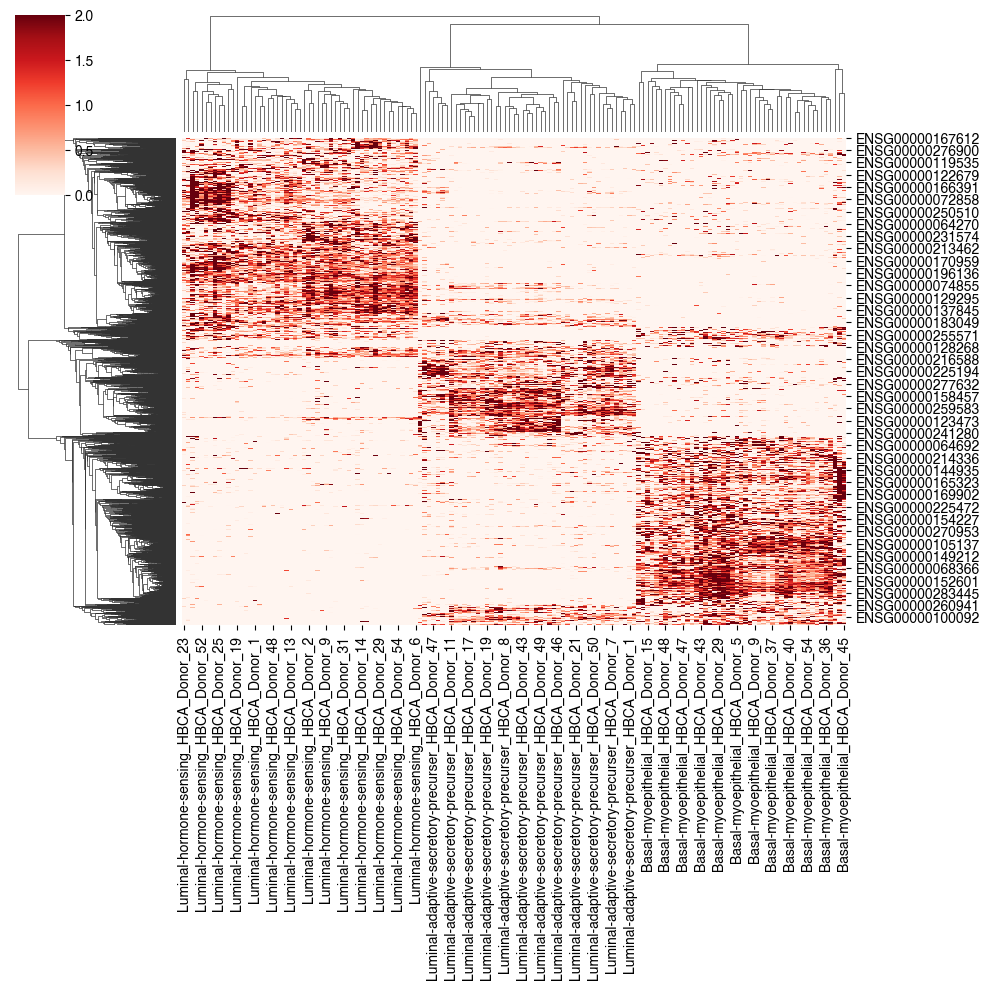

In [13]:
cg = sns.clustermap(zscore(exprtmp.T, axis=1), metric='cosine', cmap='Reds', vmin=0, vmax=2)


In [14]:
import cooler
chrom_size_path = '/large_experiments/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


## 3Ccluster diff loop

In [23]:
res = 10000
L2_meta = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0)
L2_annot = L2_meta['celltype_L2_both_abbr'].to_dict()


In [15]:
loopdir = f'{ENTEX_ROOT}/analysis/diff_loop/EpiBrst/'
loopall = pd.read_hdf(f'{loopdir}merged_loop.hdf', key='data')
loopq = pd.read_hdf(f'{loopdir}loop_Q.hdf', key='data')
loopt = pd.read_hdf(f'{loopdir}loop_T.hdf', key='data')


In [16]:
from scipy.stats import norm, zscore

thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)
fdrthres = 0.01


1.9599639845400545 1.0364333894937898


In [17]:
statfilter = (zscore(np.log10(loopall['Qanova']))>thres2) & (zscore(np.log10(loopall['Tanova']))>thres2)
fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
selloop = statfilter # & fdrfilter
print(statfilter.sum(), fdrfilter.sum(), selloop.sum())


70949 103048 70949


In [18]:
diffloop = loopall.loc[selloop, [0,1,4]]
diffloop[[1, 4]] = diffloop[[1, 4]] // res
diffloop = diffloop.reset_index()
diffloop


,index,0,1,4
0,261,chr1,192,204
1,273,chr1,193,204
2,274,chr1,193,205
3,275,chr1,193,206
4,286,chr1,194,204
...,...,...,...,...
70944,1110022,chr22,5052,5058
70945,1110023,chr22,5052,5059
70946,1110024,chr22,5052,5060
70947,1110025,chr22,5052,5061


In [19]:
data = pd.read_csv(f'{indir}hg38.main.10kbin.TSS.slop2k.txt', sep='\t', header=None, index_col=None)
data[6] = data[6].str.split('.').str[0]
data[3] = data[0] + '-' + (data[1] // res).astype(str)
bin2gene = {xx:[] for xx in data[3].values}
data = data[data[6].isin(exprtmp.columns)]
for xx,yy in data[[3,6]].values:
    bin2gene[xx].append(yy)
    

In [20]:
selloop = []
selgene = []
for loop in diffloop[[0, 1, 4, 'index']].values:
    xx = f'{loop[0]}-{loop[1]}'
    yy = f'{loop[0]}-{loop[2]}'
    zz = bin2gene[xx] + bin2gene[yy]
    if len(zz)>0:
        selloop.append(np.repeat([loop[3]], len(zz)))
        selgene.append(zz)

selloop = np.concatenate(selloop)
selgene = np.concatenate(selgene)
print(len(selloop), len(selgene))


8070 8070


In [28]:
tmp3c = loopq.loc[selloop]
tmp3c = zscore(tmp3c, axis=1)

In [29]:
tmprna = exprtmp.loc[:, selgene].T
tmprna = zscore(tmprna, axis=1)

In [47]:
def order_row(data, nc):
    data = data.reset_index(drop=True)
    
    # Perform KMeans clustering    
    kmeans = KMeans(n_clusters=nc, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(data)

    # Create a new dataframe with cluster labels
    cluster_df = pd.DataFrame({'Cluster': clusters}, index=data.index)

    # Sort the data by cluster and plot the heatmap
    merged_data = pd.concat([data, cluster_df], axis=1).groupby(by='Cluster').mean()
    cg = sns.clustermap(merged_data, cmap='vlag', metric='cosine', figsize=(6,4))
    rorder = cg.dendrogram_row.reordered_ind.copy()
    corder = cg.dendrogram_col.reordered_ind.copy()
    
    leg = merged_data.index[rorder]
    count = pd.Series(clusters).value_counts().loc[leg]
    sorted_data = pd.concat([data[clusters==i] for i in leg], axis=0)
    
    return sorted_data, count, cluster_df, corder


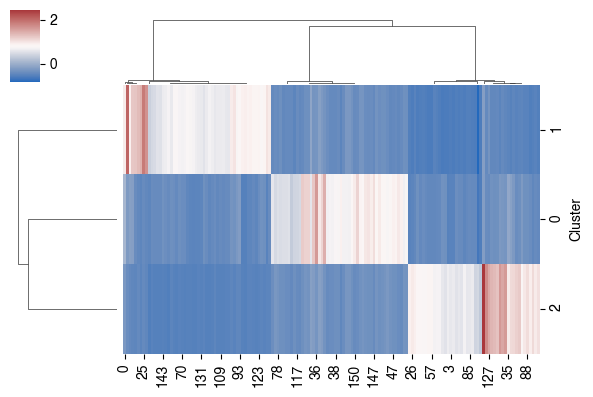

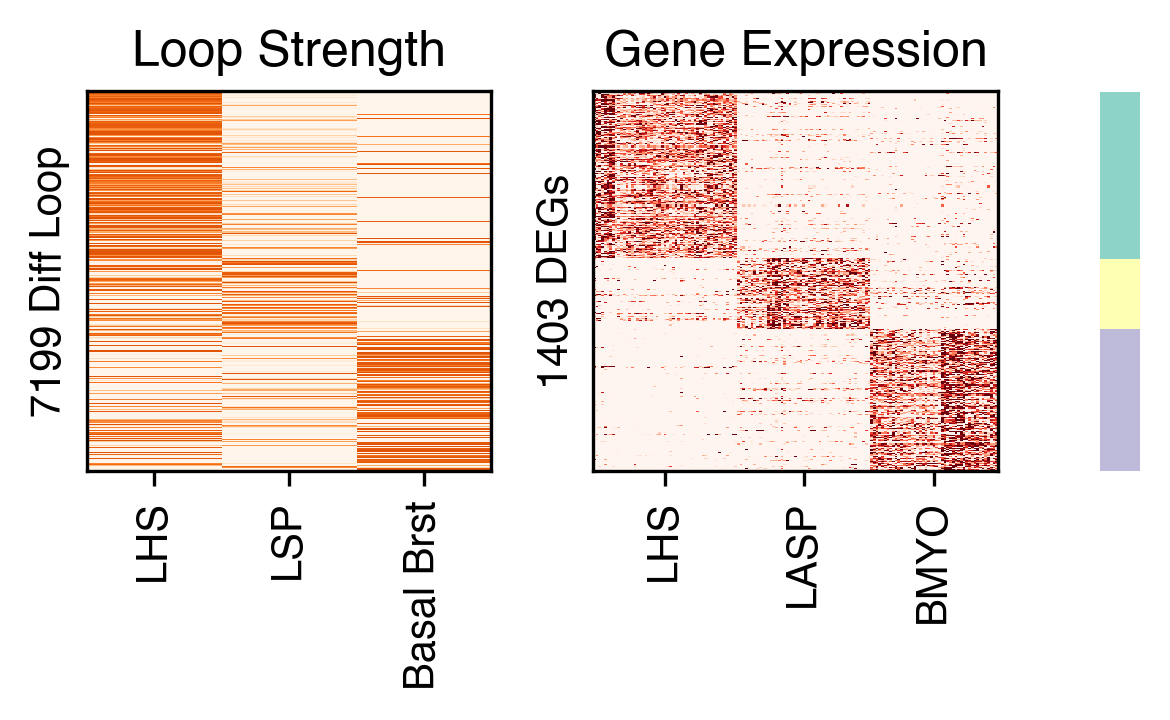

In [72]:
from sklearn.cluster import KMeans
import matplotlib.patches as patches

nc = 3
group_palette = sns.color_palette('Set3', nc)
tmp = np.concatenate([tmp3c.values, tmprna.values], axis=1)
tmp, count, label, corder = order_row(pd.DataFrame(tmp), nc=nc)
corder = pd.Index(corder)
corder_3c = corder[corder<len(leg)]
corder_rna = corder[corder>=len(leg)] - len(leg)

fig, axes = plt.subplots(1, 3, figsize=(4,2.5), dpi=300, sharey='all', 
                         gridspec_kw={'width_ratios': [10, 10, 1]})

ax = axes[0]
ax.imshow(tmp3c.iloc[tmp.index, corder_3c], cmap='Oranges', aspect='auto', 
          interpolation='none', rasterized=True, vmin=0, vmax=2)
ax.set_xticks(np.arange(tmp3c.shape[1]))
ax.set_xticklabels(tmp3c.columns[corder_3c].map(L2_annot), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{np.unique(selloop).shape[0]} Diff Loop')
ax.set_title('Loop Strength')

ax = axes[1]
ax.imshow(tmprna.iloc[tmp.index, corder_rna], cmap='Reds', aspect='auto', 
          vmin=0, vmax=2, interpolation='none', rasterized=True)
xticks = pd.Series(tmprna.columns[corder_rna].str.split('_').str[0]).reset_index().groupby(0)['index'].mean().sort_values()
ax.set_xticks(xticks)
ax.set_xticklabels(xticks.index.map(legmap), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{np.unique(selgene).shape[0]} DEGs')
ax.set_title('Gene Expression')

ax = axes[2]
offset = [0] + list(count.cumsum())
ax.axis('off')
for k in range(nc):
    rect = patches.Rectangle((0, offset[k]), 1, offset[k+1]-offset[k], linewidth=0, 
                             edgecolor='none', facecolor=group_palette[k])
    ax.add_patch(rect)

fig.tight_layout()
fig.savefig(f'{outdir}EpiBrst_diffloop_deg_heatmap.pdf', transparent=True)

# ax.set_yticks(count.cumsum()-0.5)
# ax.set_yticklabels(count.index)


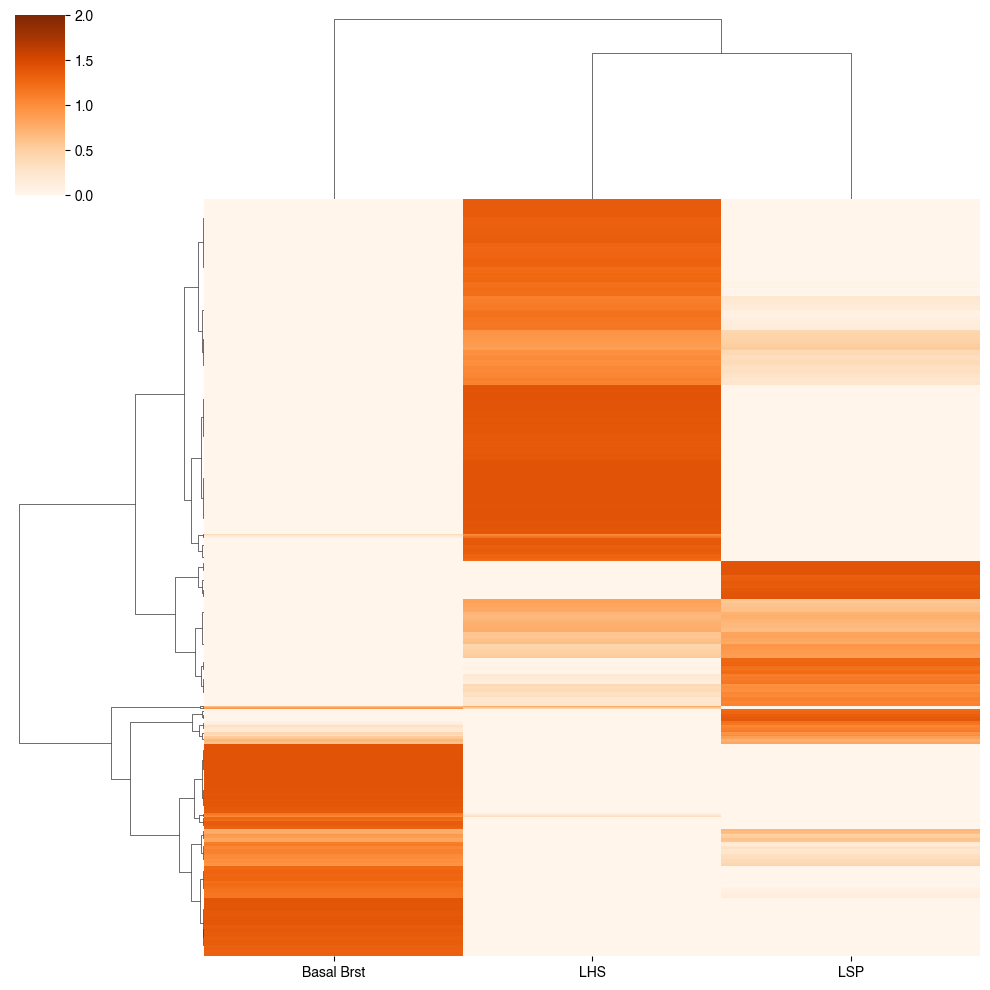

In [24]:
cg = sns.clustermap(tmp3c, cmap='Oranges', vmin=0, vmax=2, metric='cosine', 
                    xticklabels=loopq.columns.map(L2_annot), yticklabels=[])


In [25]:
rorder_3c = cg.dendrogram_row.reordered_ind.copy()
corder_3c = cg.dendrogram_col.reordered_ind.copy()

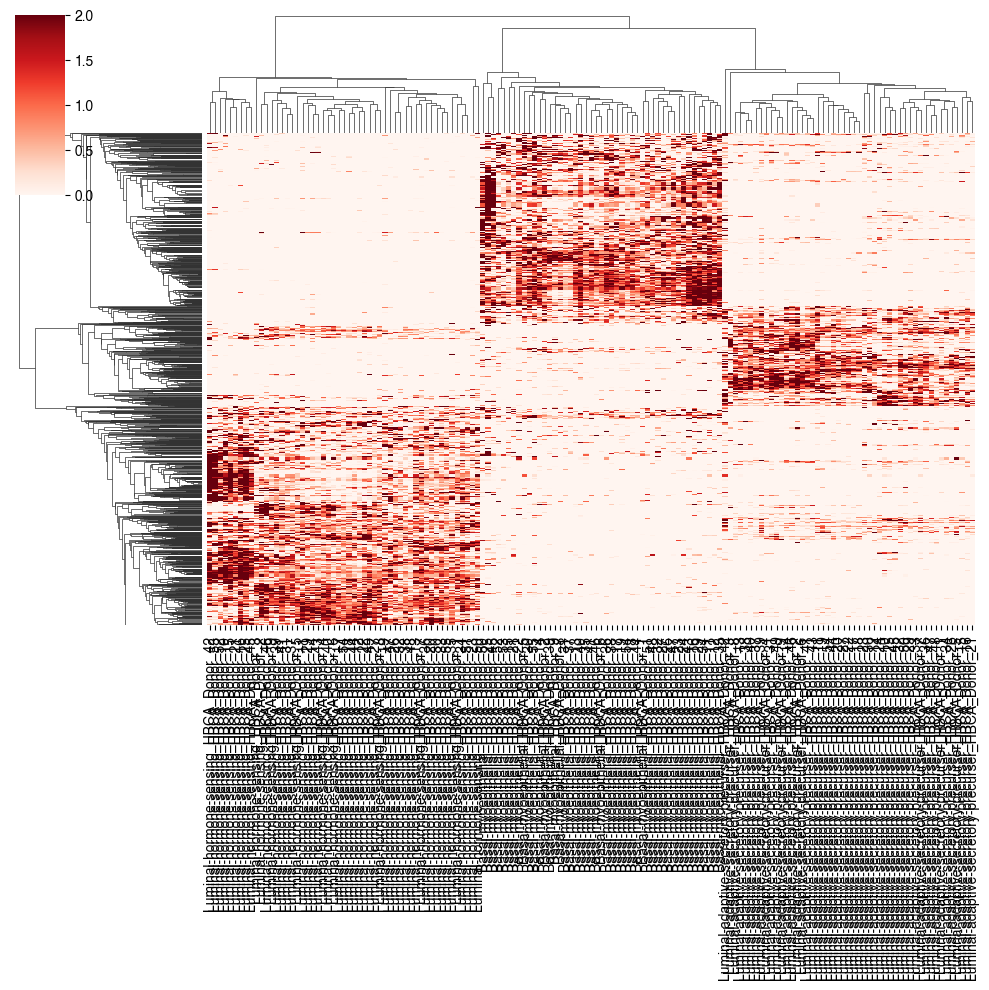

In [60]:
cg = sns.clustermap(tmprna, cmap='Reds', vmin=0, vmax=2, metric='cosine', xticklabels=exprtmp.index, yticklabels=[])


In [26]:
rorder_rna = cg.dendrogram_row.reordered_ind.copy()
corder_rna = cg.dendrogram_col.reordered_ind.copy()

In [76]:
pd.Series(selgene).map(ens2gene).value_counts()

AC104237.3    60
CCDC68        56
OXTR          50
PRLR          46
AL390294.1    46
              ..
ARHGAP20       1
IL18           1
S100A14        1
S100A2         1
GORAB-AS1      1
Name: count, Length: 1403, dtype: int64

In [82]:
leg = pd.Index(['c18-b0', 'c18-b1', 'c25-b0'])
cooldir = f'{indir}loop/subtype/'


In [91]:
gtmp = 'OXTR'
lslop, rslop = 1000000, 1000000

chrom, start, end, strand = gene_meta.loc[gene_meta['gene_name']==gtmp, ['chrom', 'start', 'end', 'strand']].iloc[0]
if strand=='+':
    tss = start
else:
    tss = end

ll, rr = (tss - lslop), (tss + rslop)
print(chrom, ll, rr)


chr3 7769628 9769628


In [92]:
resl = 10000
loopl, loopr = (ll//resl), (rr//resl)
print(loopl, loopr)

776 976


In [93]:
## Load cell type Q

from scipy import ndimage as nd

dstall = []
for ct in leg:
    cool = cooler.Cooler(f'{cooldir}{ct}/{ct}.Q.cool')
    Q = cool.matrix(balance=False, sparse=True).fetch(chrom).tocsr()
    tmp = Q[loopl:loopr, loopl:loopr].toarray()
    dstall.append(tmp)
    print(ct)
    

c18-b0
c18-b1
c25-b0


In [124]:
loopr

976

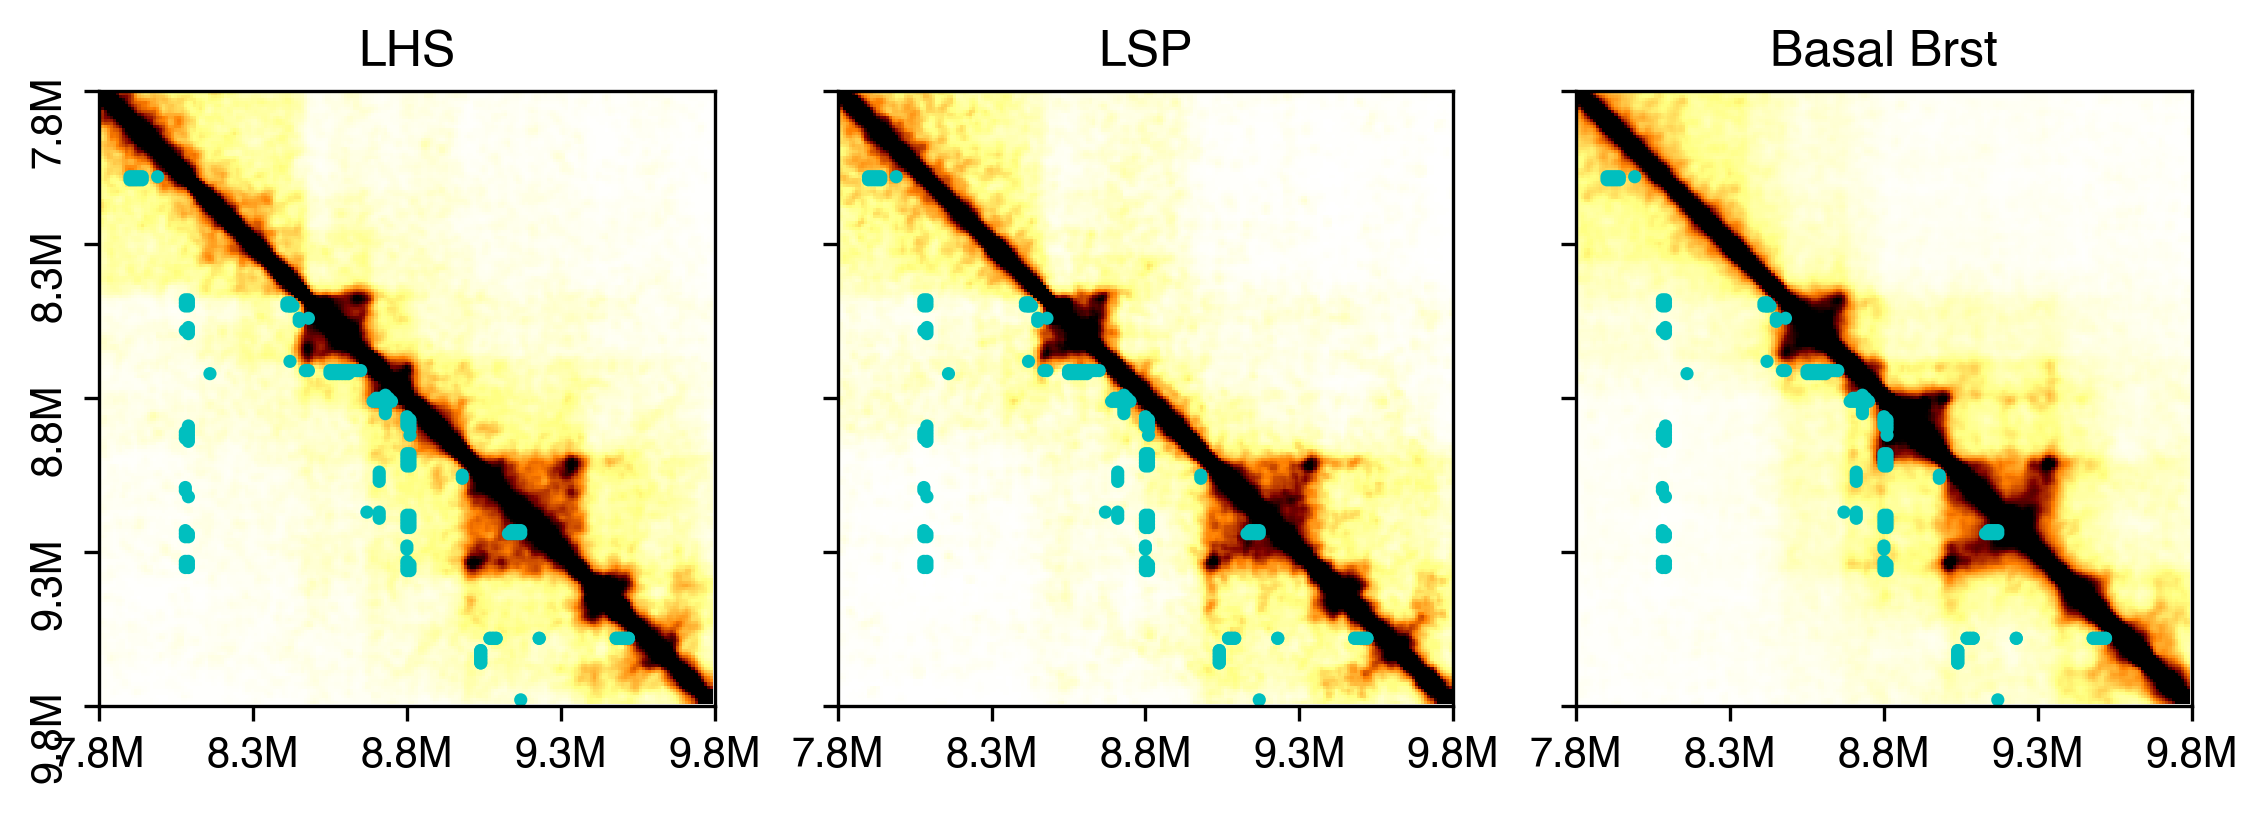

In [122]:
fig, axes = plt.subplots(1, len(leg), figsize=(3*len(leg), 3), sharex='all', sharey='all', dpi=300)

## differential feature position at 10k resolution
tmpl = loopall.loc[selloop, [1,4]] // resl - loopl
tmpl = tmpl.loc[(tmpl[1]>0) & (tmpl[4]<(loopr-loopl))].values

for i in range(len(leg)):
    ax = axes[i]
    # ax.axis('equal')
    ax.set_title(leg.map(L2_annot)[i])
    img = ax.imshow(dstall[i], cmap='afmhot_r', vmin=0, vmax=0.012)
    ## plot diff loop
    ax.scatter(tmpl[:, 0], tmpl[:, 1], alpha=1, s=10, marker='o', edgecolors='none', color='c', rasterized=True)

    ax.set_xlim([0, loopr-loopl])
    ax.set_ylim([loopr-loopl, 0])
    step = (loopr-loopl)//4
    ticks = np.arange(0, loopr-loopl+1, step)
    ticklabels = [f'{np.around(xx*resl/1e6, decimals=1)}M' for xx in np.arange(loopl, loopr+1, step)]
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels, fontsize=10, rotation=90)

# fig.tight_layout()
fig.savefig(f'{outdir}diffloop_{gtmp}.pdf', transparent=True, dpi=300)
